# Lending Club Case Study

This notebook follows the analysis narrative in the README and focuses on:
- Profitability and platform sustainability trends
- Customer segmentation and product mix
- Market penetration opportunities (state-level analysis)
- Data quality improvements for downstream analytics

In [34]:
# Imports
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from statsmodels.stats.proportion import proportions_chisquare
from sklearn.preprocessing import MinMaxScaler

# Display options
pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_rows = 50
pd.options.display.max_columns = 20

# Dataset paths (Kaggle layout)
loan_path = '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv'
dict_path = '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/LCDataDictionary.xlsx'
us_pop_path = '/kaggle/input/datasets/fr999yyy/uspop-2018/2018 pop.csv'

In [35]:
columns_to_select = [
    # Customer profile
    'addr_state', 'zip_code', 'emp_title', 'emp_length', 'purpose', 'home_ownership', 'annual_inc',
    # Segment profitability
    'int_rate',
    # Cash flow attributes
    'funded_amnt', 'total_pymnt', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    # Time attributes
    'loan_status', 'issue_d', 'earliest_cr_line', 'inq_last_6mths',
    'last_pymnt_d', 'last_credit_pull_d', 'term',
    # Retention & upsell
    'dti', 'grade',
]

df = pd.read_csv(loan_path, usecols=columns_to_select).drop_duplicates()

In [36]:
pop_df = pd.read_csv(us_pop_path)
pop_df = pop_df.set_index('States')
pop_df = pop_df.replace({',': ''}, regex=True).astype(float)

pop_df.head()

,2010,2011,2012,2013,2014,2015,2016,2017,2018
States,,,,,,,,,
Alabama,4785448.0000,4798834.0000,4815564.0000,4830460.0000,4842481.0000,4853160.0000,4864745.0000,4875120.0000,4887871.0000
Alaska,713906.0000,722038.0000,730399.0000,737045.0000,736307.0000,737547.0000,741504.0000,739786.0000,737438.0000
Arizona,6407774.0000,6473497.0000,6556629.0000,6634999.0000,6733840.0000,6833596.0000,6945452.0000,7048876.0000,7171646.0000
Arkansas,2921978.0000,2940407.0000,2952109.0000,2959549.0000,2967726.0000,2978407.0000,2990410.0000,3002997.0000,3013825.0000
California,37320903.0000,37641823.0000,37960782.0000,38280824.0000,38625139.0000,38953142.0000,39209127.0000,39399349.0000,39557045.0000


In [37]:
df.shape

(2260668, 23)

The dataset contains about 2.26M records.

# Data cleaning

1. Remove duplications
2. Standardize
3. Null or Blank values
4. Remove any columns

There are emojis, symbols, and tab characters in the `emp_title` field, so I use regex to remove noise before bucketing and fuzzy matching.

To improve interpretability, I standardize `emp_title` into an `audience_segment` that reflects sector and persona.

I took the 500 most common titles and used AI to propose keyword mappings for the bucketing logic.

By checking management keywords before professional ones, a title like "Sales Manager" is correctly categorized as Management instead of Labor/Service (triggered by "Sales").

Most remaining unclassified titles in the top 500 list are specialized professional roles (e.g., "Graphic Artist" or "Policy Analyst"), so the remainder defaults to "Professional".

About 23% of job titles remain unclassified; I keep them as a data-quality flag for follow-up.

Purpose is fully standardized and cleaned. We'll move on to `addr_state` and `zip_code`

First, use `addr_state` to identify high-performance regions (e.g., "Texas and New York have the highest ROI").
Then use `zip_code` to find hotspots within those regions (e.g., "Within Texas, profit is driven primarily by these 5 high-growth ZIP codes in Austin and Dallas") to reduce marketing CAC.

Earlier we discovered negative values in the `dti` field. To avoid skewing risk, convert `-1` to 0.
We also use DTI to predict payment stability for upsell personas; to reduce outlier impact, winsorize at the 99th percentile. The cap is reasonable since most lenders treat DTI above 50% as unmanageable.

In [38]:
# --- 1. Job Segment Categorization ---
job_conditions = [
    (df['emp_title'].isna()) | (df['emp_title'].str.strip() == ''),
    (df['emp_title'].str.contains(r'owner|founder|ceo|cmo|cfo|coo|president|vice president|vp|director|executive|chief|avp|partner|principal|proprietor|freelance|entrepreneur', case=False, na=False)),
    (df['emp_title'].str.contains(r'nurse|rn|lpn|cna|physician|doctor|pharmacist|attorney|lawyer|engineer|analyst|accountant|controller|consultant|specialist|therapist|dentist|psychologist|chemist|scientist|underwriter|advisor|developer|programmer|software|paralegal|accounting|bookkeeper|audit|legal|physiotherapist|hygienist|paramedic|designer|it|actuary', case=False, na=False)),
    (df['emp_title'].str.contains(r'teacher|professor|police|officer|firefighter|correctional|social worker|military|army|navy|air force|deputy|sheriff|detective|soldier|instructor|counselor|pastor|clergyman|letter carrier|postal|mail|security|sergeant|captain|investigator|educator', case=False, na=False)),
    (df['emp_title'].str.contains(r'sales|realtor|broker|representative|rep|agent|marketing|account executive|account manager|merchandiser|buyer|real estate|estimator', case=False, na=False)),
    (df['emp_title'].str.contains(r'manager|supervisor|foreman|superintendent|lead|head|coordinator|management|administrator|administration|admin', case=False, na=False)),
    (df['emp_title'].str.contains(r'mechanic|electrician|machinist|welder|carpenter|technician|tech|driver|operator|maintenance|janitor|custodian|plumber|hvac|painter|laborer|warehouse|production|fitter|worker|fabricator|truck|flight attendant|pilot|assembler|installer|material handler|labor', case=False, na=False)),
    (df['emp_title'].str.contains(r'assistant|clerk|secretary|receptionist|server|bartender|cook|cashier|associate|teller|customer service|dispatcher|scheduler|chef|waitress|caregiver|attendant|banker|concierge|csr|recruiter|human resources|hr', case=False, na=False))
]

job_choices = [
    'Unknown', 'Executives & Business Owners', 'Skilled Professionals',
    'Public Sector & Education', 'Sales & Marketing', 'Management',
    'Skilled Trades & Logistics', 'Administrative & Service'
]

df['audience_segment'] = np.select(job_conditions, job_choices, default='Other/Unclassified')

# --- 2. State Lookup & Quality Tag ---
state_map = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California',
    'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia',
    'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland',
    'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri',
    'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey',
    'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont',
    'VA': 'Virginia', 'WA': 'Washington', 'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming',
    'DC': 'District of Columbia'
}

df['state_full_name'] = df['addr_state'].map(state_map).fillna('Unknown')
df['data_quality_tag'] = np.where(df['state_full_name'] == 'Unknown', 'Missing/Invalid', 'Valid')

# --- 3. Home Ownership Consolidation ---
df['home_status'] = df['home_ownership'].replace(['ANY', 'OTHER'], 'OTHER')

# --- 4. DTI Cleaning & Winsorization (p99 Capping) ---
df['dti_final'] = df['dti'].apply(lambda x: 0 if pd.isna(x) or x < 0 else x)
p99 = df.loc[df['dti'] >= 0, 'dti'].quantile(0.99)
df['dti_final'] = df['dti_final'].clip(upper=p99)

# --- 5. Date Parsing & Metric Calculation ---
# Note: Format '%b-%Y' parses 'Jan-2023'
df['issue_date'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['last_pymnt_date'] = pd.to_datetime(df['last_pymnt_d'], format='%b-%Y')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')

# Calculate days held and credit age
df['days_held'] = (df['last_pymnt_date'] - df['issue_date']).dt.days
df['credit_age'] = (df['issue_date'] - df['earliest_cr_line']).dt.days

# Standardize 'term' column
# 1. Strip whitespace
# 2. Remove the string ' months'
# 3. Convert to integer
df['term'] = df['term'].str.replace(' months', '', case=False).str.strip().astype(int)

df['emp_length_years'] = (
    df['emp_length']
    .str.replace(r'years|year|\+ years|>|<', '', case=False, regex=True)
    .str.strip().fillna(0)
    .astype(int)
)

# Rename the column for clarity in Tableau
df.rename(columns={'term': 'term_months'}, inplace=True)

In [39]:
status_dist = df['loan_status'].value_counts(normalize=True) * 100
status_dist

loan_status
Fully Paid                                            46.0904
Current                                               40.6824
Charged Off                                           11.5742
Late (31-120 days)                                     0.9686
In Grace Period                                        0.3960
Late (16-30 days)                                      0.1653
Does not meet the credit policy. Status:Fully Paid     0.0879
Does not meet the credit policy. Status:Charged Off    0.0337
Default                                                0.0014
Name: proportion, dtype: float64

Current loans are about 40% of the portfolio, suggesting recent growth in applications and a large active cohort.

In [40]:
# Add 'ID' column from the existing index
df = df.reset_index()
# Optionally rename the default 'index' column to 'ID'
df = df.rename(columns={'index': 'id'})

Among all the loans, only those which has settled (Fully Paid & Charge Off) can calculate realized ROI to help us analyze segment profitability.

Loans with the status of `Current` are identified as "Active" loans that haven't earned their profit yet.

Loans with the status of `Late (31-120 days)`, `Late (16-30 days)`, `In Grace Period`, and `Default` are considered at risk. While technically they're not finished, the probability of these returning to "Fully Paid" is statistically low.

In [41]:
def segment_profitability_calc(df):
    """
    Categorizes loans and calculates metrics, excluding 'premature' cohorts
    to avoid selection bias in ROI/Ann Return.
    """
    # 1. Standardize Term
    if 'term' in df.columns:
        df['term_months'] = df['term'].str.replace(' months', '', case=False).str.strip().astype(int)
    
    # Define dataset end date (Latest point in your 2018 data)
    data_end_date = pd.to_datetime('2018-12-31')

    # 2. Define the buckets
    settled_statuses = [
        'Fully Paid', 'Charged Off', 
        'Does not meet the credit policy. Status:Fully Paid', 
        'Does not meet the credit policy. Status:Charged Off'
    ]
    
    at_risk_statuses = ['Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period', 'Default']

    df['analysis_bucket'] = df['loan_status'].apply(
        lambda x: 'Settled' if x in settled_statuses else 
                  'Active' if x == 'Current' else 
                  'At Risk' if x in at_risk_statuses else 'Other'
    )

    # 3. Create Maturity Mask (The Bias Fix)
    # A cohort is "Mature" if: Issue Date + Term <= Data End Date
    # We use pd.DateOffset to shift the issue date forward by the term months
    df['is_mature'] = df.apply(
        lambda x: (x['issue_date'] + pd.DateOffset(months=x['term_months'])) <= data_end_date, 
        axis=1
    )

    # 4. Financial Calculations
    service_fee_rate = 0.01
    net_profit = (df['total_pymnt'] - df['collection_recovery_fee']) - \
                 df['funded_amnt'] - \
                 (df['total_pymnt'] * service_fee_rate)
    
    roi_raw = net_profit / df['funded_amnt']

    # Days Held Calculation
    df['days_held'] = (df['last_pymnt_date'] - df['issue_date']).dt.days
    df['days_held_adj'] = df['days_held'].clip(lower=30) 
    df['years_held'] = df['days_held_adj'] / 365.25
    
    ann_return_raw = ((1 + roi_raw.clip(lower=-0.99)) ** (1 / df['years_held'])) - 1

    # 5. Assignment with Filters
    # We ONLY assign profit/ROI/Ann_Return if:
    # a) It is in the 'Settled' bucket
    # b) The loan cohort is 'Mature' (avoids the 2015/2013 bias)
    
    calculation_filter = (df['analysis_bucket'] == 'Settled') & (df['is_mature'] == True)

    df['realized_net_profit'] = np.where(calculation_filter, net_profit, np.nan)
    
    df['roi'] = np.where(
        calculation_filter, 
        roi_raw.clip(lower=-1.0, upper=1.0), 
        np.nan
    )
    
    df['ann_return'] = np.where(
        calculation_filter, 
        ann_return_raw.clip(lower=-1.0, upper=1.0), 
        np.nan
    )
    
    return df

# Usage:
df = segment_profitability_calc(df)

36-month loans issued after 2015 and 60-month loans issued after 2013 have not fully matured by 2018. If we include them in ROI and annual return, the results would be biased toward charge-offs.

In [42]:
df.head()

,id,funded_amnt,term_months,int_rate,grade,emp_title,emp_length,home_ownership,annual_inc,issue_d,...,days_held,credit_age,emp_length_years,analysis_bucket,is_mature,days_held_adj,years_held,realized_net_profit,roi,ann_return
0,0,2500,36,13.5600,C,Chef,10+ years,RENT,55000.0000,Dec-2018,...,62.0000,6453.0000,10,Active,False,62.0000,0.1697,NaN,NaN,NaN
1,1,30000,60,18.9400,D,Postmaster,10+ years,MORTGAGE,90000.0000,Dec-2018,...,62.0000,11506.0000,10,Active,False,62.0000,0.1697,NaN,NaN,NaN
2,2,5000,36,17.9700,D,Administrative,6 years,MORTGAGE,59280.0000,Dec-2018,...,62.0000,2801.0000,6,Active,False,62.0000,0.1697,NaN,NaN,NaN
3,3,4000,36,18.9400,D,IT Supervisor,10+ years,MORTGAGE,92000.0000,Dec-2018,...,62.0000,4686.0000,10,Active,False,62.0000,0.1697,NaN,NaN,NaN
4,4,30000,60,16.1400,C,Mechanic,10+ years,MORTGAGE,57250.0000,Dec-2018,...,62.0000,6574.0000,10,Active,False,62.0000,0.1697,NaN,NaN,NaN


# EDA 

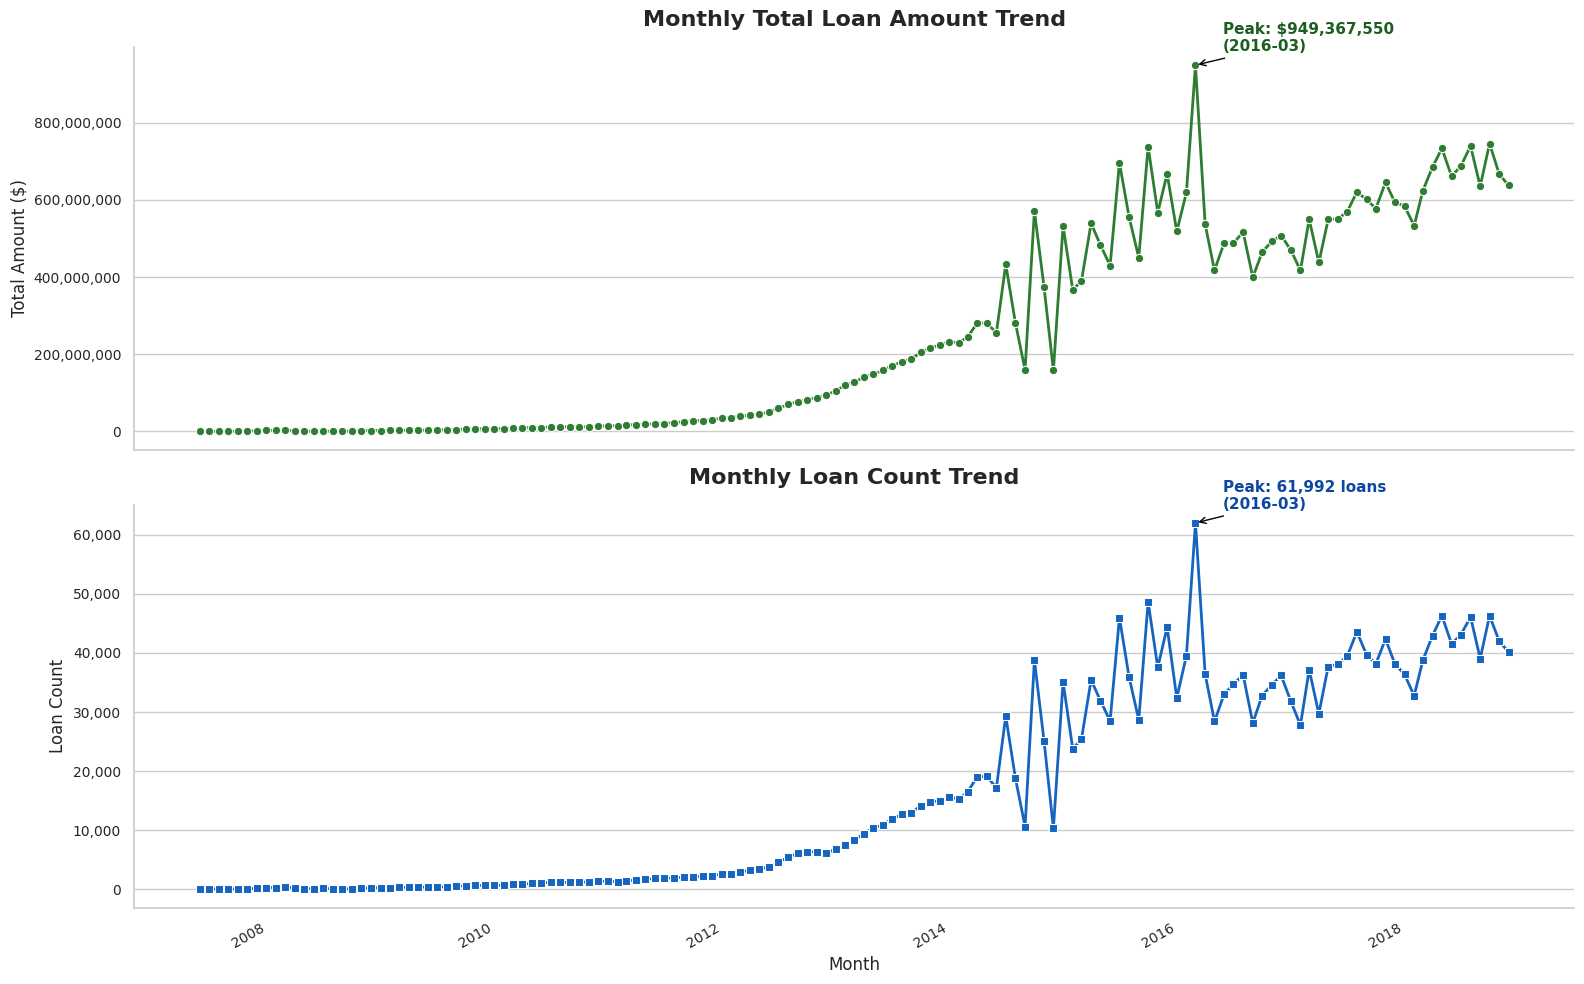

In [43]:
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# 1. Preprocessing
df['year_month_ts'] = df['issue_date'].dt.to_period('M').dt.to_timestamp()

trend_df = (
    df.groupby('year_month_ts')
    .agg(
        total_amount=('funded_amnt', 'sum'),
        loan_count=('funded_amnt', 'count'),
    )
    .reset_index()
)

# 2. Style & layout
sns.set_style("whitegrid")
COLORS = {
    'amount': '#2E7D32',
    'amount_label': '#1B5E20',
    'count': '#1565C0',
    'count_label': '#0D47A1',
}

ANNOTATION_KWARGS = dict(
    xytext=(20, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=11,
    fontweight='bold',
)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.subplots_adjust(hspace=0.08)  # tighter gap between subplots

# 3. Plot 1: Total loan amount
sns.lineplot(
    data=trend_df, x='year_month_ts', y='total_amount',
    ax=ax1, color=COLORS['amount'], marker='o', linewidth=2,
)
ax1.set_title('Monthly Total Loan Amount Trend', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Total Amount ($)', fontsize=12)
ax1.set_xlabel('')

peak_amt = trend_df.loc[trend_df['total_amount'].idxmax()]
ax1.annotate(
    f"Peak: ${peak_amt['total_amount']:,.0f}\n({peak_amt['year_month_ts'].strftime('%Y-%m')})",
    xy=(peak_amt['year_month_ts'], peak_amt['total_amount']),
    color=COLORS['amount_label'],
    **ANNOTATION_KWARGS,
)

# 4. Plot 2: Loan count
sns.lineplot(
    data=trend_df, x='year_month_ts', y='loan_count',
    ax=ax2, color=COLORS['count'], marker='s', linewidth=2,
)
ax2.set_title('Monthly Loan Count Trend', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Loan Count', fontsize=12)
ax2.set_xlabel('Month', fontsize=12)

peak_cnt = trend_df.loc[trend_df['loan_count'].idxmax()]
ax2.annotate(
    f"Peak: {peak_cnt['loan_count']:,} loans\n({peak_cnt['year_month_ts'].strftime('%Y-%m')})",
    xy=(peak_cnt['year_month_ts'], peak_cnt['loan_count']),
    color=COLORS['count_label'],
    **ANNOTATION_KWARGS,
)

# ── 5. X-axis formatting ──────────────────────────────────────────────────────
# ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))   # "Jan 2020" is easier to read than "2020-01"
# ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))   # every 6 months instead of 2
# ax2.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))   # subtle tick every month

plt.xticks(rotation=30, ha='right', fontsize=10)               # shallower angle, right-aligned

# clean up both axes
for ax in (ax1, ax2):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(axis='x', visible=False)   # remove vertical gridlines, keep horizontal only

plt.tight_layout()
plt.savefig('Loan_amount_and_count_trend.png')
plt.show()

In March 2016, Lending Club's loan amount and volume both reached their historical peaks. We will attempt to further investigate the underlying causes using existing data.

Unlike loan purposes, which are more susceptible to seasonal fluctuations (such as tax season, Thanksgiving, and Black Friday), credit grades are generally more stable. Their volatility often reflects shifts in company policy or broader macroeconomic changes. Therefore, we will begin by analyzing the changes in the distribution of credit grades.

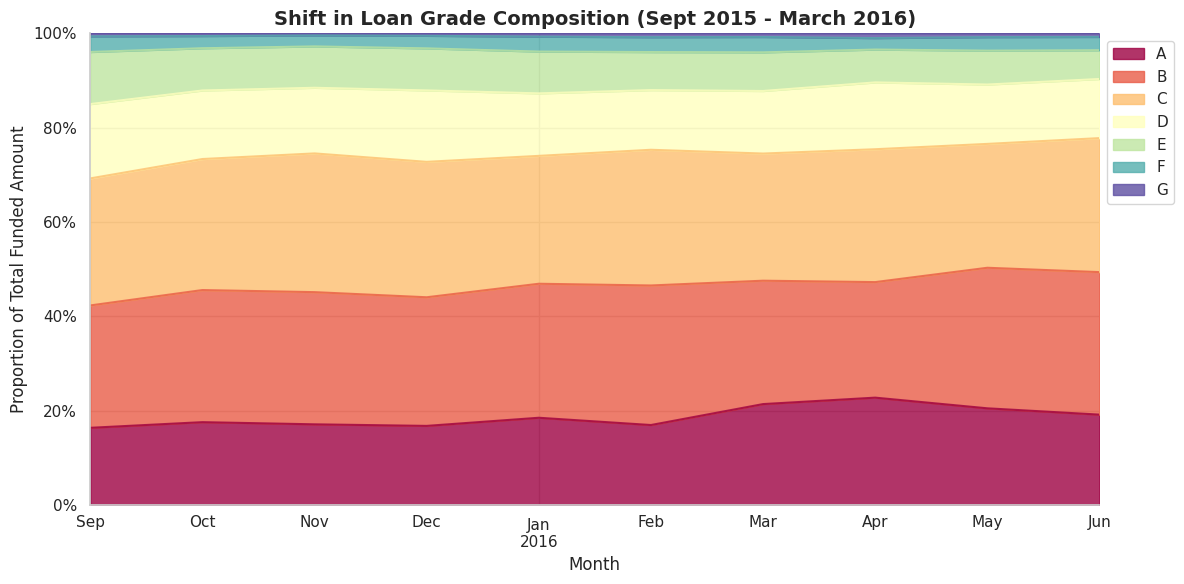

In [44]:
# 1. Filter the specific window
mask = (df['issue_date'] >= '2015-09-01') & (df['issue_date'] <= '2016-06-01')
df_window = df[mask].copy()

# 2. Prepare the proportional data (using 'grade' as an example)
# You can swap 'grade' with 'purpose' to check both
pivot_df = df_window.groupby([df_window['issue_date'].dt.to_period('M'), 'grade'])['funded_amnt'].sum().unstack().fillna(0)

# Convert to percentages (0.0 to 1.0)
pivot_perc = pivot_df.divide(pivot_df.sum(axis=1), axis=0)
pivot_perc.index = pivot_perc.index.to_timestamp()

# 3. Plotting
plt.figure(figsize=(12, 6))
pivot_perc.plot(kind='area', stacked=True, ax=plt.gca(), colormap='Spectral', alpha=0.8)

plt.title('Shift in Loan Grade Composition (Sept 2015 - March 2016)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion of Total Funded Amount')
plt.xlabel('Month')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, 1)

# Format Y-axis as percentage
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('loan_grade_trend_2015Q3.png')
plt.show()

Compared to Q4 2015, the proportion of Grade A loans approved in Q1 2016 (March) rose by approximately 5%, while other credit grades showed no significant change. By Q2 2016 (June), overall credit quality exhibited a gradual upward trend, with the combined share of Grade A-C loans increasing by about 10%. This indicates that the growth contribution during Lending Club's peak loan volume period was primarily driven by high-credit-quality borrowers.

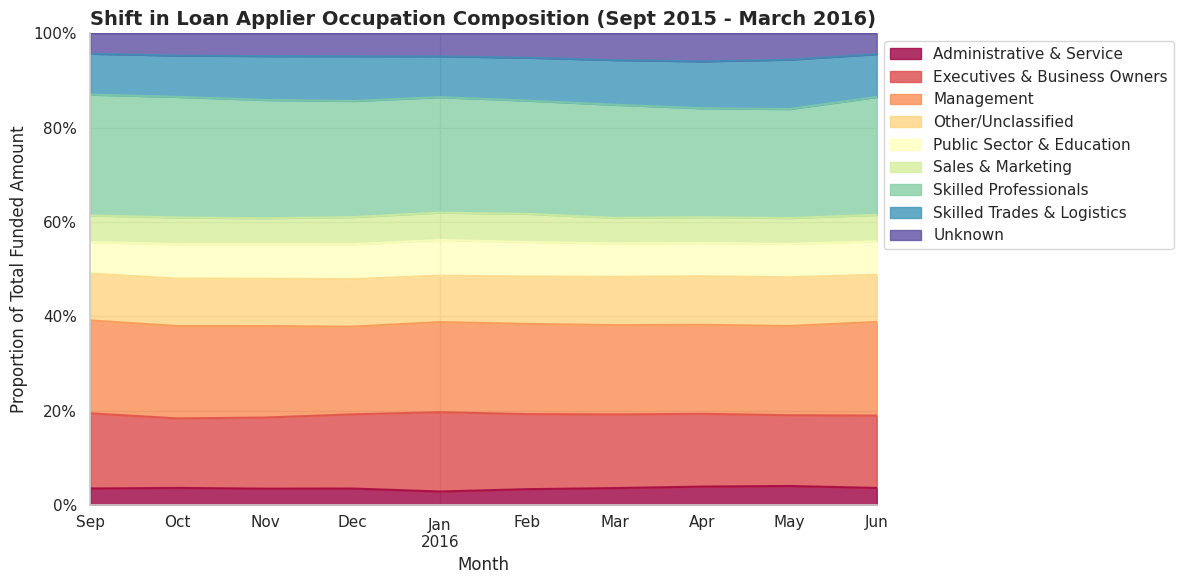

In [45]:
# 1. Filter the specific window
mask = (df['issue_date'] >= '2015-09-01') & (df['issue_date'] <= '2016-06-01')
df_window = df[mask].copy()

# 2. Prepare the proportional data (using 'grade' as an example)
# You can swap 'grade' with 'purpose' to check both
pivot_df = df_window.groupby([df_window['issue_date'].dt.to_period('M'), 'audience_segment'])['funded_amnt'].sum().unstack().fillna(0)

# Convert to percentages (0.0 to 1.0)
pivot_perc = pivot_df.divide(pivot_df.sum(axis=1), axis=0)
pivot_perc.index = pivot_perc.index.to_timestamp()

# 3. Plotting
plt.figure(figsize=(12, 6))
pivot_perc.plot(kind='area', stacked=True, ax=plt.gca(), colormap='Spectral', alpha=0.8)

plt.title('Shift in Loan Applier Occupation Composition (Sept 2015 - March 2016)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion of Total Funded Amount')
plt.xlabel('Month')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, 1)

# Format Y-axis as percentage
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('loan_job_trend_2015Q3.png')
plt.show()

The occupational composition of borrowers showed no significant changes during this period, particularly leading up to March 2016.

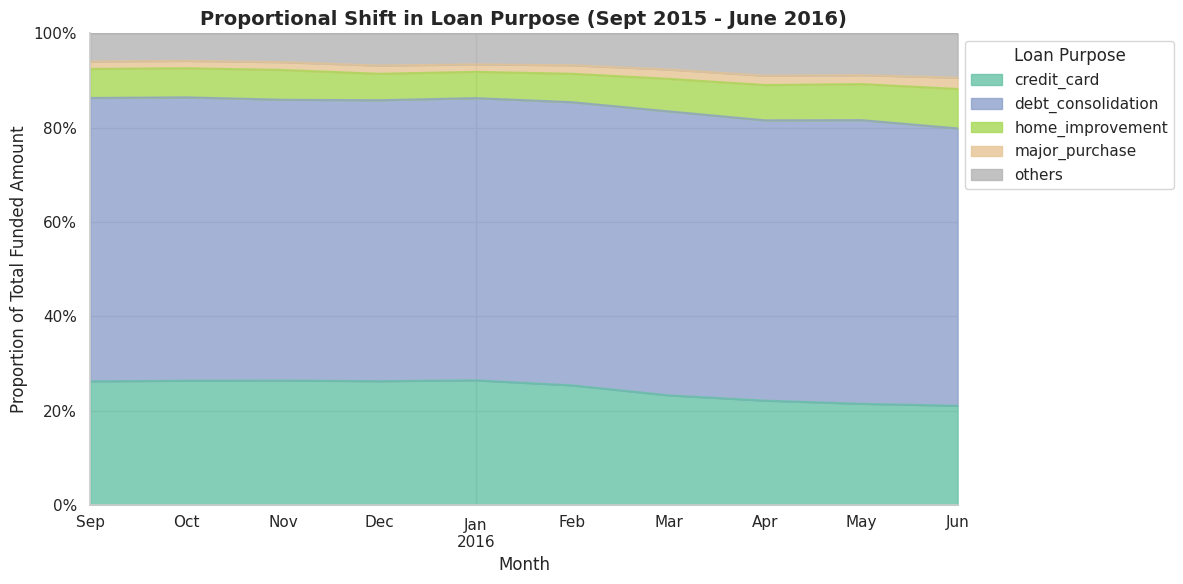

In [46]:
# 1. Filter the specific window
mask = (df['issue_date'] >= '2015-09-01') & (df['issue_date'] <= '2016-06-01')
df_window = df[mask].copy()

# 2. Bucket the 'purpose' column
top_purposes = ['credit_card', 'debt_consolidation', 'home_improvement', 'major_purchase']
df_window['purpose_bucketed'] = df_window['purpose'].where(df_window['purpose'].isin(top_purposes), 'others')

# 3. Prepare the proportional data using the new bucketed column
pivot_df = df_window.groupby([df_window['issue_date'].dt.to_period('M'), 'purpose_bucketed'])['funded_amnt'].sum().unstack().fillna(0)

# Convert to percentages (0.0 to 1.0)
pivot_perc = pivot_df.divide(pivot_df.sum(axis=1), axis=0)
pivot_perc.index = pivot_perc.index.to_timestamp()

# 4. Plotting
plt.figure(figsize=(12, 6))
# Using a cleaner colormap for fewer categories
pivot_perc.plot(kind='area', stacked=True, ax=plt.gca(), colormap='Set2', alpha=0.8)

plt.title('Proportional Shift in Loan Purpose (Sept 2015 - June 2016)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion of Total Funded Amount')
plt.xlabel('Month')

# Move legend and clean up labels
plt.legend(title='Loan Purpose', loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, 1)

# Format Y-axis as percentage
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('loan_purpose_trend_2015Q3.png')
plt.show()

As shown in the charts, no significant structural changes were observed in the composition of loan purposes or borrower occupations.

Combining the shifts in credit grade distribution with the macroeconomic environment of the time, we can derive a preliminary hypothesis regarding the 2016 Q1 loan volume peak. When the Federal Reserve initiated a rate hike cycle in late 2015, rising borrowing costs for banks and institutional investors reduced their appetite for high-risk, low-reward assets. Furthermore, concerns that rising rates could trigger an economic slowdown suggested that lower-grade borrowers on the platform would be more prone to default.

To retain both institutional and retail investors, Lending Club had to offer safer credit products, strategically focusing on higher-grade loans and proactively approving a larger volume of "prime" borrowers (Grades A and B). However, since high-grade loans carry both lower risk and lower interest rates, the resulting compressed margin meant that Lending Club required a significantly larger total loan volume to offset the decline in per-loan profitability. Simultaneously, anticipated future rate hikes incentivized borrowers to pull forward their demand to Q1 to lock in more favorable rates. In summary, shifting macroeconomic conditions drove both borrower demand and Lending Club’s supply, culminating in the loan volume peak of 2016 Q1.

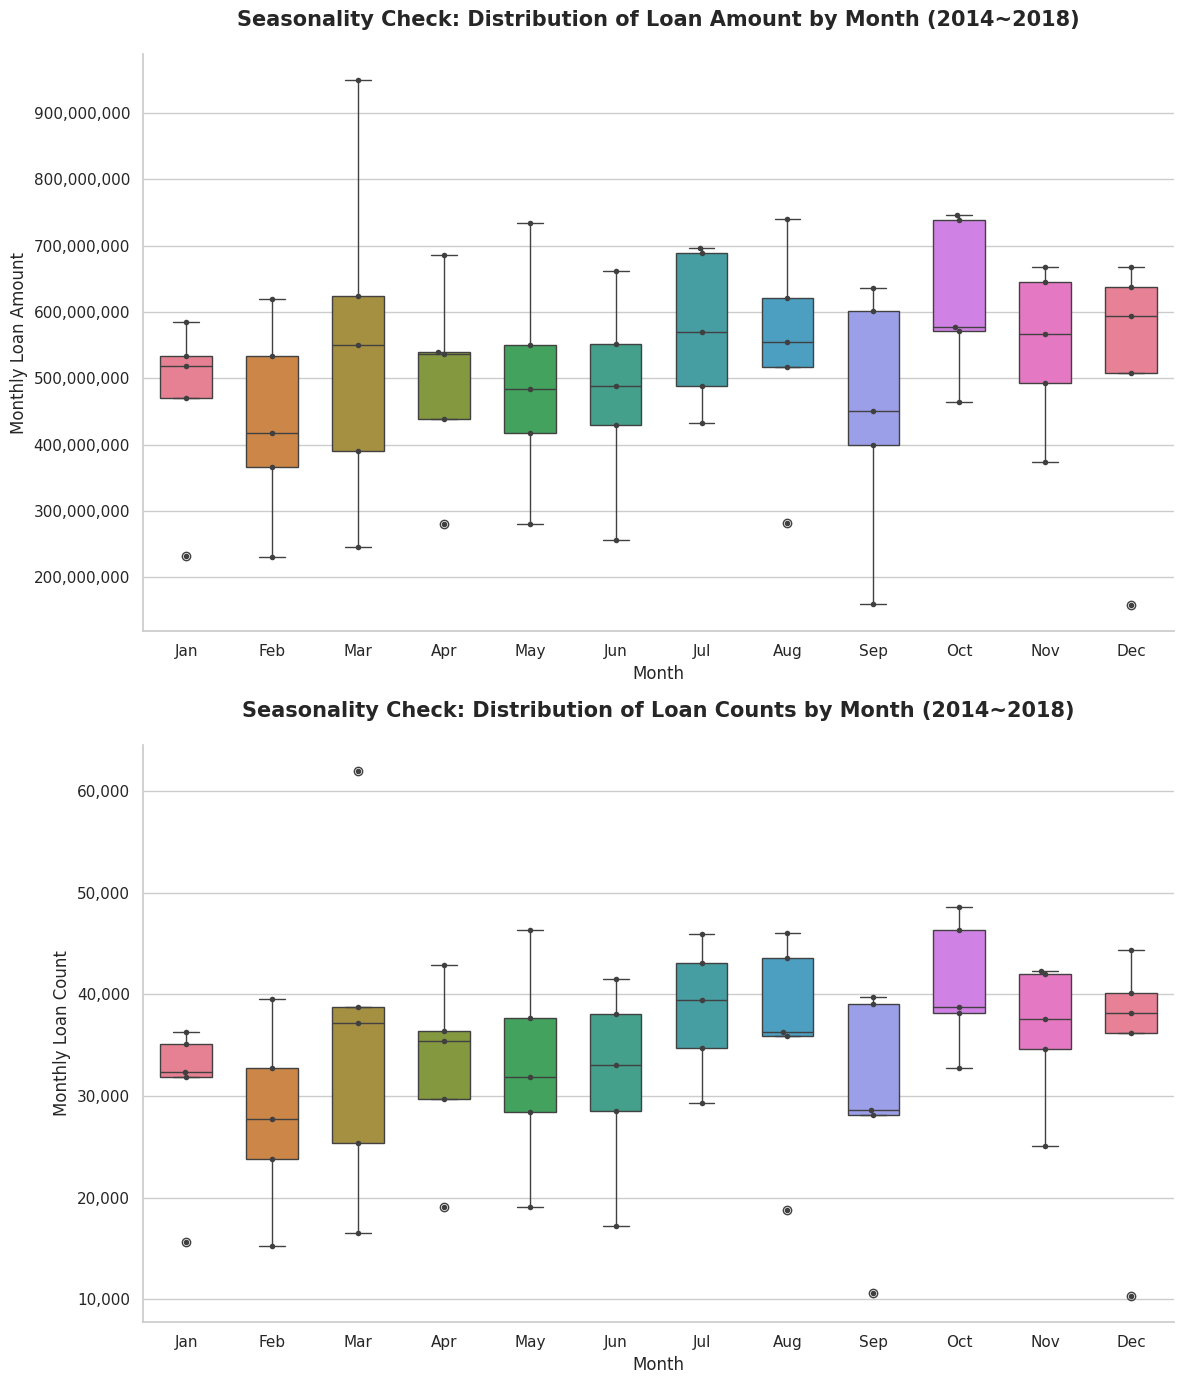

In [47]:
# 1. filter data after 2014
df_post_2014 = df[df['issue_date'].dt.year >= 2014].copy()

# 2. extract year and mont
df_post_2014['year'] = df_post_2014['issue_date'].dt.year
df_post_2014['month'] = df_post_2014['issue_date'].dt.month

# 3. aggregate amount and count
seasonality_amt = df_post_2014.groupby(['year', 'month'])['funded_amnt'].sum().reset_index()
seasonality_cnt = df_post_2014.groupby(['year', 'month']).size().reset_index(name='loan_count')

# 4. subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))
sns.set_style("whitegrid")

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Loan Amount
sns.boxplot(data=seasonality_amt, x='month', y='funded_amnt',
            hue='month', palette='husl', legend=False, width=0.6, ax=ax1)
sns.swarmplot(data=seasonality_amt, x='month', y='funded_amnt',
              color=".25", size=4, ax=ax1)
ax1.set_title('Seasonality Check: Distribution of Loan Amount by Month (2014~2018)',
              fontsize=15, fontweight='bold', pad=20)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Monthly Loan Amount', fontsize=12)
ax1.set_xticks(range(0, 12))
ax1.set_xticklabels(month_labels)
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Loan Count 
sns.boxplot(data=seasonality_cnt, x='month', y='loan_count',
            hue='month', palette='husl', legend=False, width=0.6, ax=ax2)
sns.swarmplot(data=seasonality_cnt, x='month', y='loan_count',
              color=".25", size=4, ax=ax2)
ax2.set_title('Seasonality Check: Distribution of Loan Counts by Month (2014~2018)',
              fontsize=15, fontweight='bold', pad=20)
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Monthly Loan Count', fontsize=12)
ax2.set_xticks(range(0, 12))
ax2.set_xticklabels(month_labels)
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.savefig('seasonality_2014-2018.png')
plt.show()

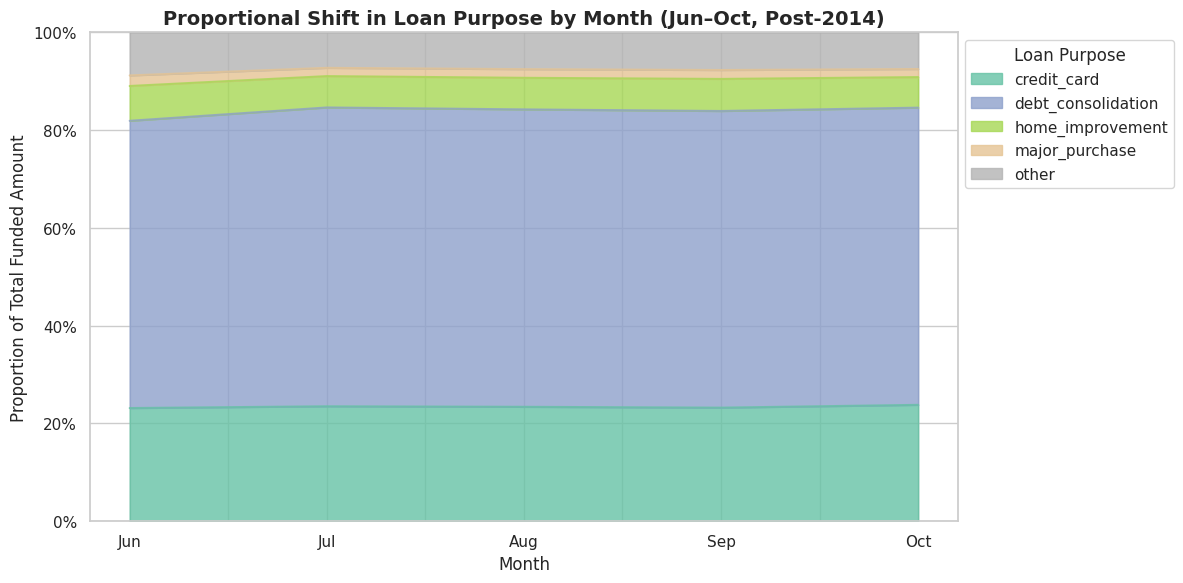

In [48]:
import calendar
from matplotlib import ticker

# 1. Filter June to October, post-2014
mask = (
    (df['issue_date'] >= '2014-01-01') &
    (df['issue_date'].dt.month >= 6) &
    (df['issue_date'].dt.month <= 10)
)
df_window = df[mask].copy()

# 2. Bucket purpose
top_purposes = ['credit_card', 'debt_consolidation', 'home_improvement', 'major_purchase']
df_window['purpose_bucketed'] = df_window['purpose'].where(
    df_window['purpose'].isin(top_purposes), 'other'
)

# 3. Group by month number (aggregated across all years) and bucketed purpose
pivot_df = (
    df_window.groupby([
        df_window['issue_date'].dt.month,
        'purpose_bucketed'
    ])['funded_amnt']
    .sum()
    .unstack()
    .fillna(0)
)

# 4. Replace month numbers with abbreviated month names
pivot_df.index = [calendar.month_abbr[m] for m in pivot_df.index]

# 5. Convert to proportions
pivot_perc = pivot_df.divide(pivot_df.sum(axis=1), axis=0)

# 6. Plot
fig, ax = plt.subplots(figsize=(12, 6))
pivot_perc.plot(kind='area', stacked=True, ax=ax, colormap='Set2', alpha=0.8)

plt.title('Proportional Shift in Loan Purpose by Month (Jun–Oct, Post-2014)', fontsize=14, fontweight='bold')
plt.ylabel('Proportion of Total Funded Amount')
plt.xlabel('Month')
plt.legend(title='Loan Purpose', loc='upper left', bbox_to_anchor=(1, 1))
plt.ylim(0, 1)
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('Shift in Loan Purpose by Month.png')
plt.show()

In [49]:
import pandas as pd

# 1. Prepare Time Attribute
# Convert issue_date to datetime and filter for the year 2018
df['issue_date'] = pd.to_datetime(df['issue_date'])
df_2018 = df[df['issue_date'].dt.year == 2018]




# 2. Aggregate Loan Data by State
# Sum total loan volume and count the number of loans per state
state_groups = df_2018.groupby('state_full_name')['funded_amnt'].agg(['sum', 'count', 'mean'])
state_groups.columns = ['total_loan_amount', 'loan_count', 'avg_loan_size']

# 3. Merge with Population Data
# Assuming pop_df index = State Full Name and column 2018 = Population
analysis_df = state_groups.join(pop_df['2018'])
analysis_df.rename(columns={'2018': 'population_2018'}, inplace=True)

# 4. Calculate Per Capita Metrics
# Loan size per capita (Total $ / Population)
analysis_df['loan_size_per_capita'] = analysis_df['total_loan_amount'] / analysis_df['population_2018']

# Loan count per capita (Number of Loans / Population)
analysis_df['loan_count_per_capita'] = analysis_df['loan_count'] / analysis_df['population_2018']

# Display results
analysis_df[['loan_size_per_capita', 'loan_count_per_capita', 'avg_loan_size']].head()

,loan_size_per_capita,loan_count_per_capita,avg_loan_size
state_full_name,,,
Alabama,17.8395,0.0011,15559.7698
Alaska,26.3927,0.0014,18536.1905
Arizona,26.1903,0.0017,15460.3280
Arkansas,18.9741,0.0013,15009.0682
California,28.0794,0.0017,16512.3931


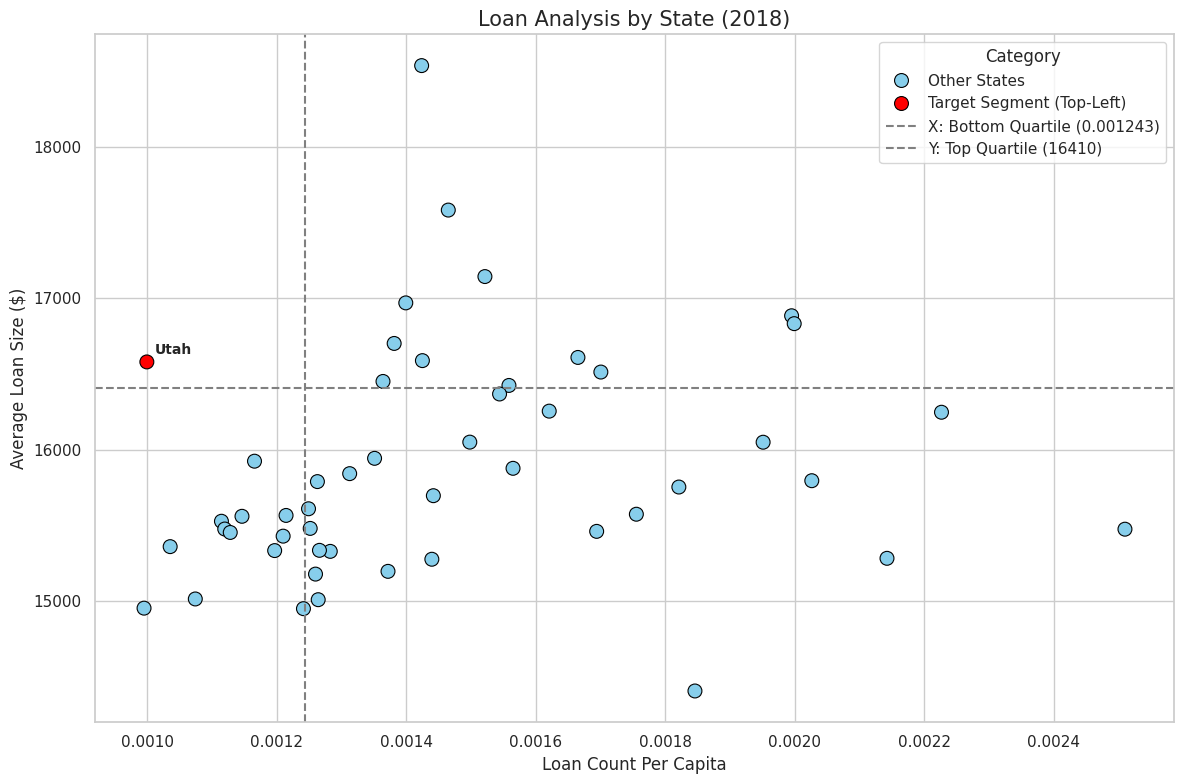

In [50]:

# 1. calculate threshould value
x_threshold = analysis_df['loan_count_per_capita'].quantile(0.25) # Bottom Quartile
y_threshold = analysis_df['avg_loan_size'].quantile(0.75)        # Top Quartile

# 2. define label
def identify_segment(row):
    if row['avg_loan_size'] >= y_threshold and row['loan_count_per_capita'] <= x_threshold:
        return 'Target Segment (Top-Left)'
    return 'Other States'

analysis_df['segment'] = analysis_df.apply(identify_segment, axis=1)

# 3. plotting
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# color scatter plot based on dimension
scatter = sns.scatterplot(
    data=analysis_df, 
    x='loan_count_per_capita', 
    y='avg_loan_size', 
    hue='segment', 
    palette={'Target Segment (Top-Left)': 'red', 'Other States': 'skyblue'},
    s=100, 
    edgecolor='black'
)

# 4. draw dimension lines
plt.axvline(x_threshold, color='grey', linestyle='--', label=f'X: Bottom Quartile ({x_threshold:.6f})')
plt.axhline(y_threshold, color='grey', linestyle='--', label=f'Y: Top Quartile ({y_threshold:.0f})')

# 5. label the state name on the upper-left
for i in range(analysis_df.shape[0]):
    if analysis_df.iloc[i]['segment'] == 'Target Segment (Top-Left)':
        plt.text(
            analysis_df.iloc[i]['loan_count_per_capita'] + (x_threshold*0.01), 
            analysis_df.iloc[i]['avg_loan_size'] + 50, 
            analysis_df.index[i], 
            fontsize=10, 
            fontweight='bold'
        )

# 6. plot details
plt.title('Loan Analysis by State (2018)', fontsize=15)
plt.xlabel('Loan Count Per Capita', fontsize=12)
plt.ylabel('Average Loan Size ($)', fontsize=12)
plt.legend(title='Category', loc='upper right')

plt.tight_layout()
plt.savefig('Loan Analysis by State (2018).png')
plt.show()


In [51]:
# 1. Define the thresholds using quantiles
top_quartile_avg_loan = analysis_df['avg_loan_size'].quantile(0.75)
bottom_quartile_count_pc = analysis_df['loan_count_per_capita'].quantile(0.25)
sample_threshold = analysis_df['loan_count'].quantile(0.1)
# 2. Apply the filters
# Condition 1: Average loan size is in the top 25%
# Condition 2: Loan count per capita is in the bottom 25%
# Condition 3: Sample size is large enough. Loan count > 10% percentile
filtered_states = analysis_df[
    (analysis_df['avg_loan_size'] >= top_quartile_avg_loan) & 
    (analysis_df['loan_count_per_capita'] <= bottom_quartile_count_pc) &
    (analysis_df['loan_count'] >= sample_threshold)
]

# 3. Display the results
print(f"Top Quartile Avg Loan Size: {top_quartile_avg_loan:.2f}")
print(f"Bottom Quartile Loan Count Per Capita: {bottom_quartile_count_pc:.6f}")
print("\nStates meeting both conditions:")
filtered_states[['avg_loan_size', 'loan_count_per_capita', 'loan_size_per_capita']]

Top Quartile Avg Loan Size: 16409.88
Bottom Quartile Loan Count Per Capita: 0.001243

States meeting both conditions:


,avg_loan_size,loan_count_per_capita,loan_size_per_capita
state_full_name,,,
Utah,16579.2880,0.0010,16.5735


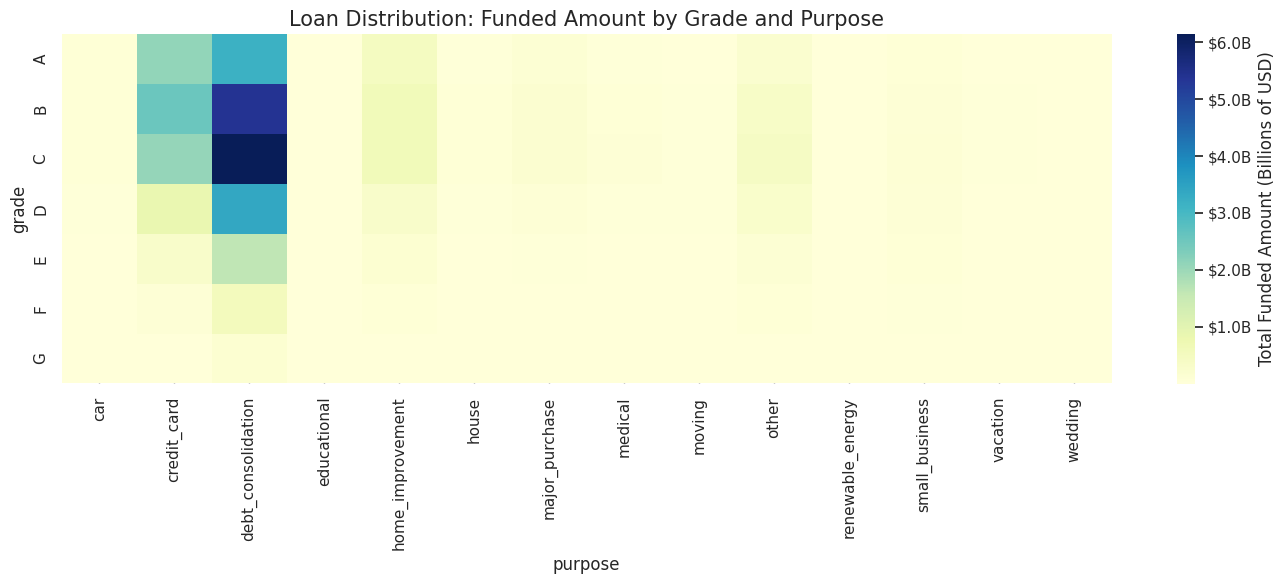

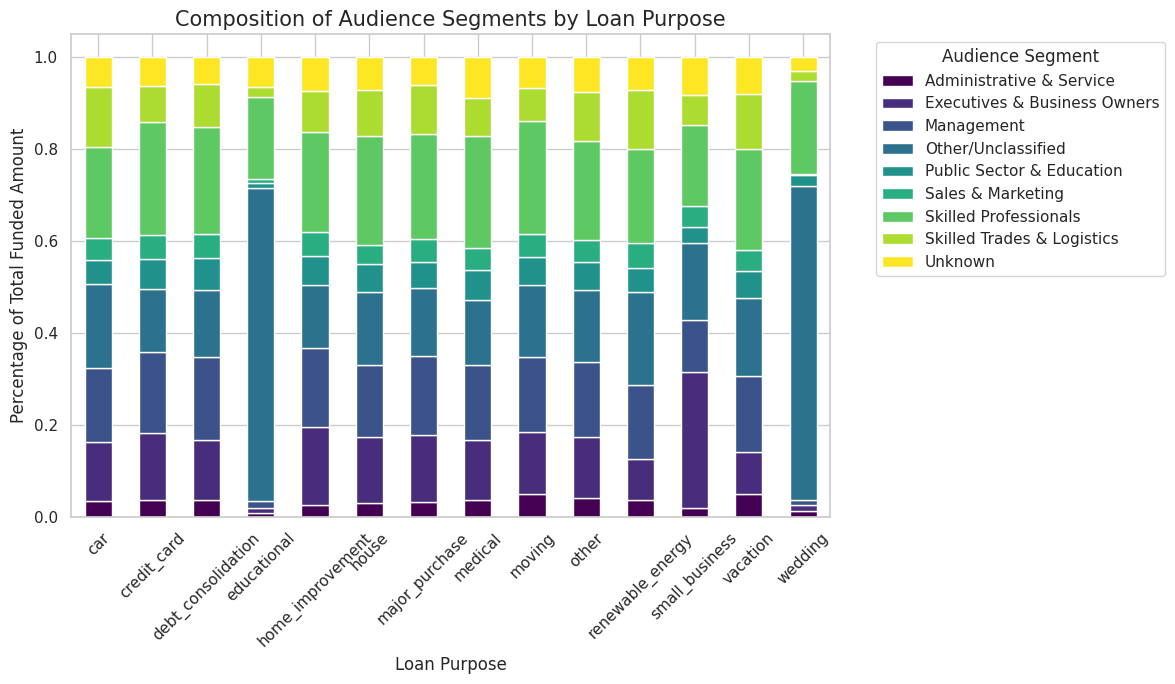

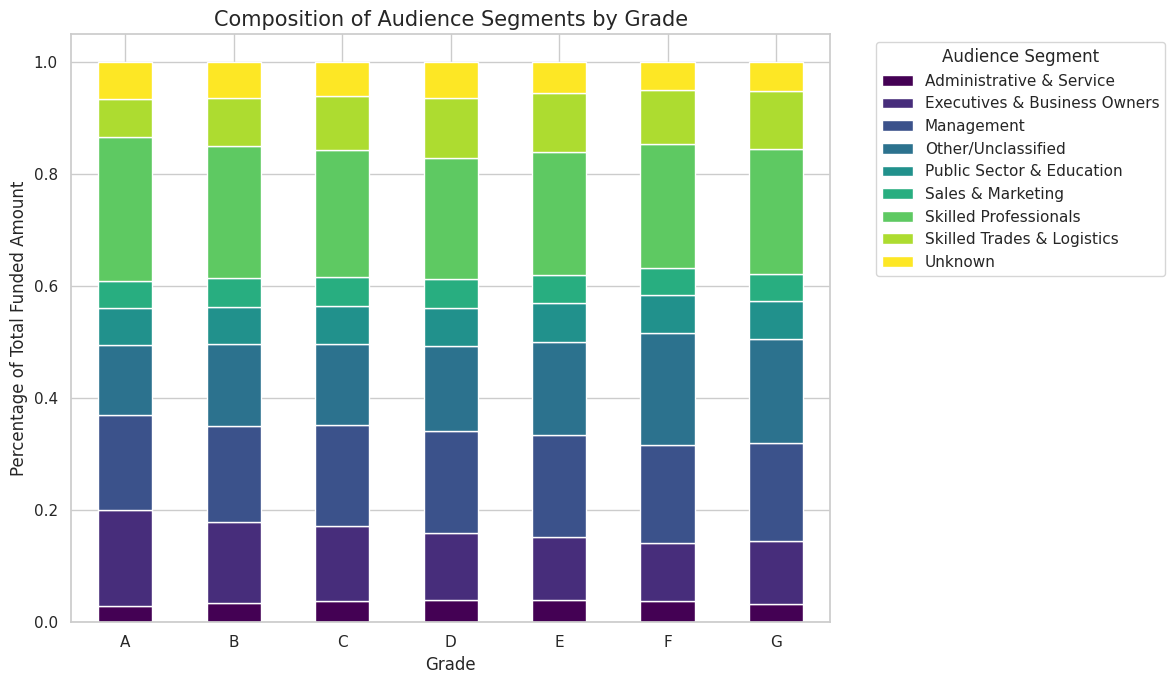

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_funding_composition(df):
    """
    Generates visualizations to show where funded amount is concentrated
    across purpose, grade, and audience segments.
    """
    # Set the visual style
    sns.set_theme(style="whitegrid")

    # 1. Total dollars by Grade & Purpose
    volume_pivot = df.pivot_table(
        index='grade',
        columns='purpose',
        values='funded_amnt',
        aggfunc='sum'
    )
    plt.figure(figsize=(14, 6))
    formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1e9:.1f}B')

    sns.heatmap(
        volume_pivot,
        annot=False,
        cmap="YlGnBu",
        cbar_kws={
            'label': 'Total Funded Amount (Billions of USD)',
            'format': formatter
        }
    )

    plt.title('Loan Distribution: Funded Amount by Grade and Purpose', fontsize=15)
    plt.tight_layout()
    plt.savefig('loan_distribution_grade_and_purpose.png')
    plt.show()

    # 2. Composition: Audience segment within each purpose
    pivot_df = df.groupby(['purpose', 'audience_segment'])['funded_amnt'].sum().unstack().fillna(0)
    pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, 7))
    pivot_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

    plt.title('Composition of Audience Segments by Loan Purpose', fontsize=15)
    plt.ylabel('Percentage of Total Funded Amount', fontsize=12)
    plt.xlabel('Loan Purpose', fontsize=12)
    plt.legend(title='Audience Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3. Composition: Audience segment within each grade
    pivot_df = df.groupby(['grade', 'audience_segment'])['funded_amnt'].sum().unstack().fillna(0)
    pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0)

    fig, ax = plt.subplots(figsize=(12, 7))
    pivot_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

    plt.title('Composition of Audience Segments by Grade', fontsize=15)
    plt.ylabel('Percentage of Total Funded Amount', fontsize=12)
    plt.xlabel('Grade', fontsize=12)
    plt.legend(title='Audience Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_funding_composition(df)

/tmp/ipykernel_57/3040810069.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


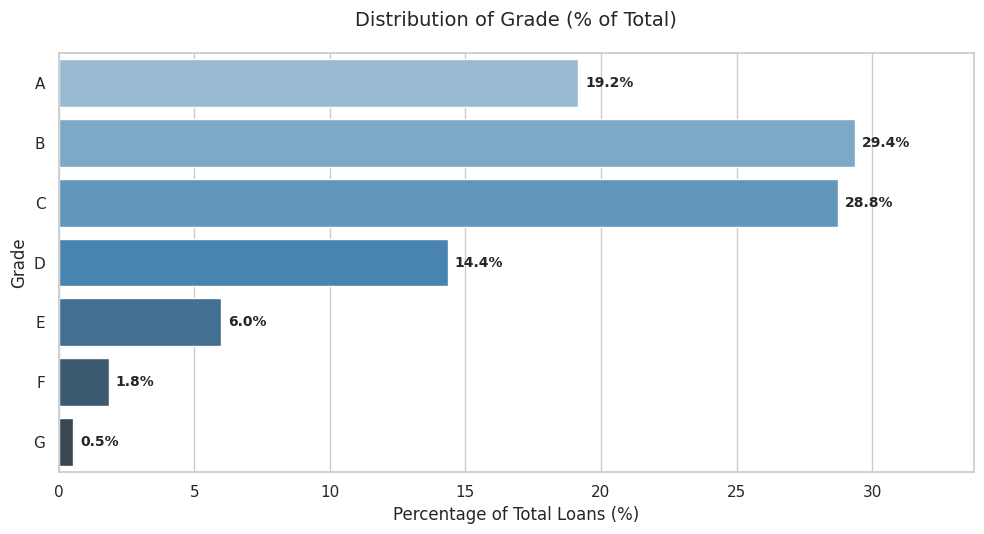

/tmp/ipykernel_57/3040810069.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


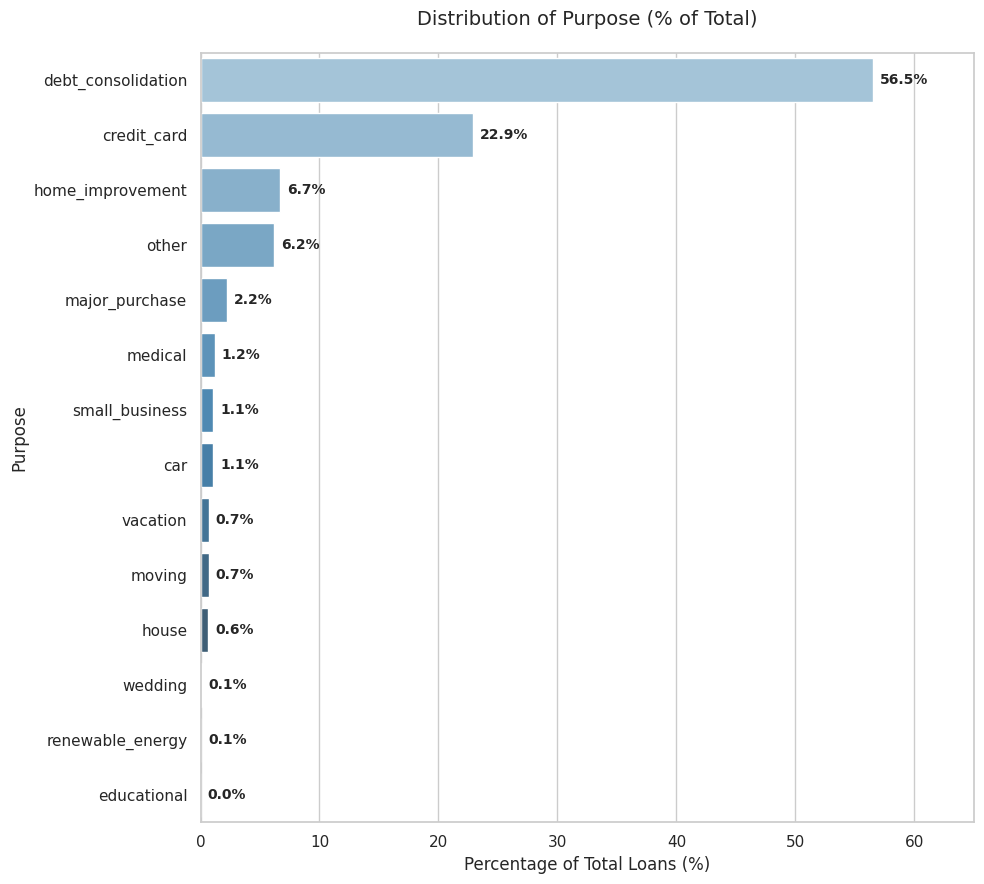

/tmp/ipykernel_57/3040810069.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


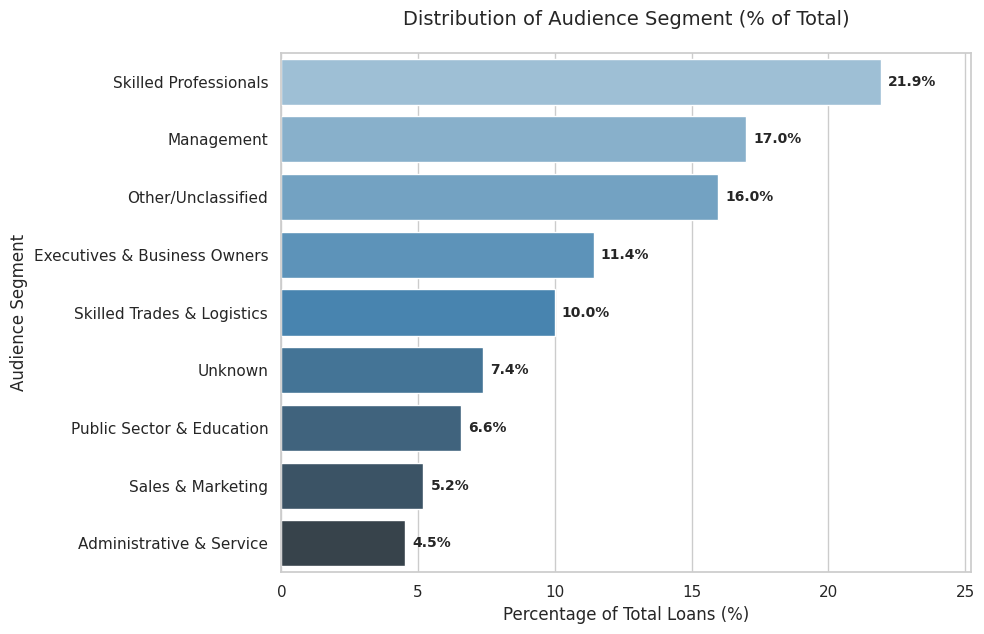

Visualizations displayed for grade, purpose, and audience segment.


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_loan_distributions(df):
    """
    Creates bar charts showing the percentage distribution of
    grade, purpose, and audience segment.
    """
    target_cols = ['grade', 'purpose', 'audience_segment']
    sns.set_theme(style="whitegrid")

    for col in target_cols:
        if col not in df.columns:
            print(f"Column '{col}' not found in DataFrame.")
            continue

        # 1. Calculate percentages
        dist = df[col].value_counts(normalize=True).reset_index()
        dist.columns = [col, 'percentage']
        dist['percentage'] = dist['percentage'] * 100

        # 2. Sorting
        if col == 'grade':
            dist = dist.sort_values(col)
        else:
            dist = dist.sort_values('percentage', ascending=False)

        # 3. Create the visualization
        fig, ax = plt.subplots(figsize=(10, len(dist) * 0.5 + 2))
        sns.barplot(
            x='percentage',
            y=col,
            data=dist,
            palette='Blues_d',
            ax=ax
        )

        # 4. Add percentage labels
        for p in ax.patches:
            width = p.get_width()
            ax.annotate(
                f'{width:.1f}%',
                (width, p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold'
            )

        # Formatting
        ax.set_title(f'Distribution of {col.replace("_", " ").title()} (% of Total)', fontsize=14, pad=20)
        ax.set_xlabel('Percentage of Total Loans (%)')
        ax.set_ylabel(col.replace("_", " ").title())
        ax.set_xlim(0, dist['percentage'].max() * 1.15)

        plt.tight_layout()
        plt.show()

    print("Visualizations displayed for grade, purpose, and audience segment.")

# Usage:
visualize_loan_distributions(df)

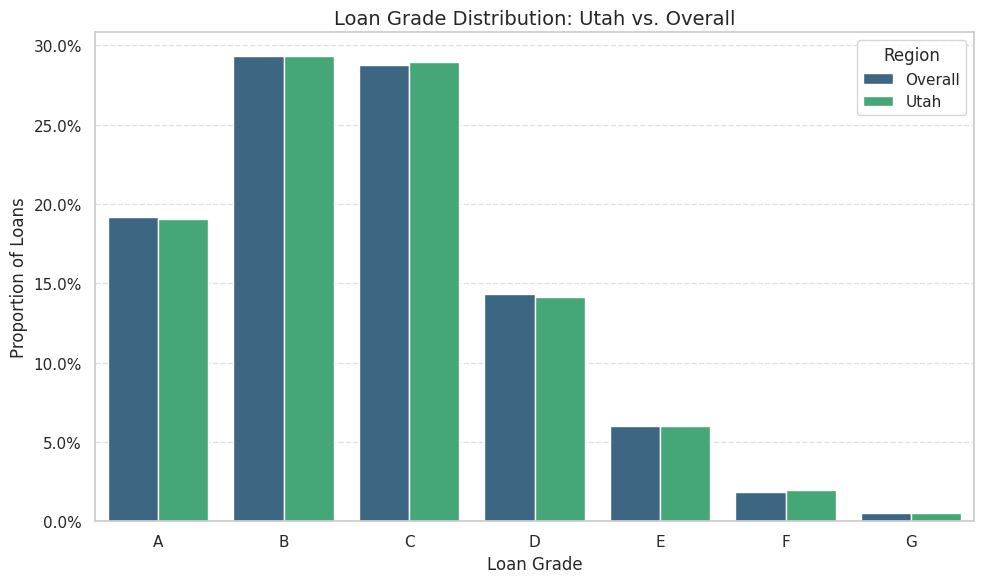

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Overall Grade Distribution (%)
overall_dist = df['grade'].value_counts(normalize=True).sort_index().reset_index()
overall_dist.columns = ['grade', 'percentage']
overall_dist['category'] = 'Overall'

# 2. Calculate Utah Grade Distribution (%)
utah_df = df[df['state_full_name'] == 'Utah']
utah_dist = utah_df['grade'].value_counts(normalize=True).sort_index().reset_index()
utah_dist.columns = ['grade', 'percentage']
utah_dist['category'] = 'Utah'

# 3. Combine for Plotting
comparison_df = pd.concat([overall_dist, utah_dist])

# 4. Create the Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='grade', y='percentage', hue='category', palette='viridis')

# 5. Formatting
plt.title('Loan Grade Distribution: Utah vs. Overall', fontsize=14)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Proportion of Loans', fontsize=12)

# Change Y-axis to percentage format
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend(title='Region', frameon=True, facecolor='white', loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('Loan Grade Distribution: Utah vs. Overall.png')
plt.show()


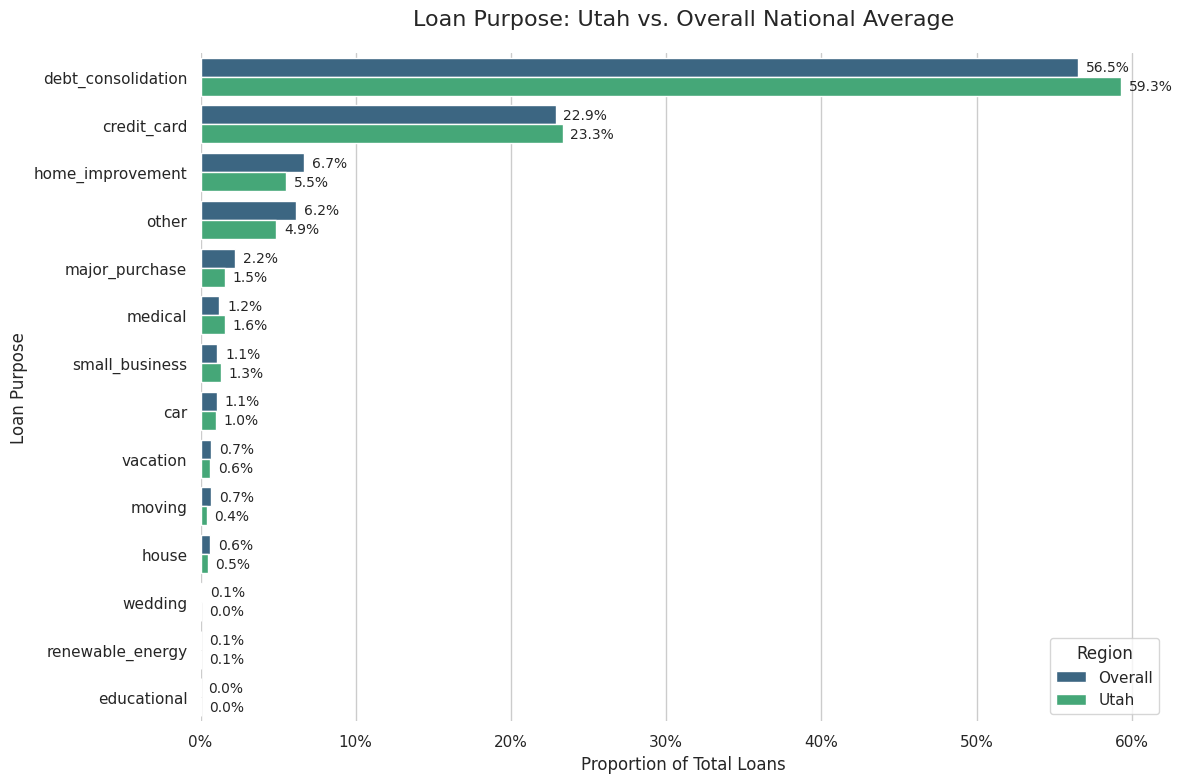

In [55]:
import matplotlib.ticker as mtick

# 1. Overall Distribution
overall_dist = df['purpose'].value_counts(normalize=True).reset_index()
overall_dist.columns = ['purpose', 'percentage']
overall_dist['category'] = 'Overall'

# 2. Utah Distribution
utah_df = df[df['state_full_name'] == 'Utah']
utah_dist = utah_df['purpose'].value_counts(normalize=True).reset_index()
utah_dist.columns = ['purpose', 'percentage']
utah_dist['category'] = 'Utah'

# 3. Concat
comparison_df = pd.concat([overall_dist, utah_dist])

# 4. Plot readability improvement
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

plot = sns.barplot(
    data=comparison_df,
    y='purpose',
    x='percentage',
    hue='category',
    palette='viridis',
    edgecolor='white'
)

# 5. Plot Details
plt.title('Loan Purpose: Utah vs. Overall National Average', fontsize=16, pad=20)
plt.xlabel('Proportion of Total Loans', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)

# X axis percentage formatting
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Data Label
for p in plot.patches:
    width = p.get_width()
    if width > 0:
        plt.text(
            width + 0.005,
            p.get_y() + p.get_height() / 2,
            f'{width:.1%}',
            va='center', fontsize=10
        )

# Legends
plt.legend(title='Region', frameon=True, facecolor='white', loc='lower right')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('Loan Purpose: Utah vs. Overall National Average.png')
plt.show()

In [56]:
def analyze_other_category(df):
    """
    Calculates the dominance of the 'Other' category and exports 
    specific titles for further refinement.
    """
    
    # 1. Calculate the Percentage of 'Other'
    total_count = len(df)
    other_count = len(df[df['audience_segment'] == 'Other/Unclassified'])
    other_pct = (other_count / total_count) * 100
    
    print(f"--- Audience Segment Analysis ---")
    print(f"Total Loans: {total_count:,}")
    print(f"Other/Unclassified: {other_count:,} ({other_pct:.2f}%)")
    print("-" * 33)

    # 2. Extract the 'Other' list for manual inspection
    # We only care about the titles that actually have a return (Settled & Mature)
    other_list = df[
        (df['audience_segment'] == 'Other/Unclassified') & 
        (df['ann_return'].notnull())
    ].copy()

    # 3. Sort by Return Descending
    # This helps identify the 'Hidden Gems' (high profit titles we should reclassify)
    other_list_sorted = other_list[['emp_title', 'grade', 'ann_return', 'funded_amnt']].sort_values(
        by='ann_return', 
        ascending=False
    )

    # 4. Export to CSV
    other_list_sorted.to_csv('investigate_other_titles.csv', index=False)
    print("Exported 'investigate_other_titles.csv' for further classification.")
    
    return other_list_sorted

# Usage:
# other_titles_df = analyze_other_category(df)

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def run_comparative_analysis(df, target_purposes=['wedding', 'vacation', 'house', 'educational']):
    results = []
    
    # Define mature/settled filter
    mask_base = (df['analysis_bucket'] == 'Settled') & (df['is_mature'] == True)
    
    for purpose in target_purposes:
        for grade in sorted(df['grade'].unique()):
            # Filter for specific grade
            grade_df = df[mask_base & (df['grade'] == grade)].copy()
            if len(grade_df) < 50: continue # Skip if too small
            
            grade_df['is_target'] = grade_df['purpose'].str.lower() == purpose
            
            # --- 1. Default Rate Significance ---
            is_charged_off = grade_df['loan_status'].str.contains('Charged Off')
            contingency = pd.crosstab(grade_df['is_target'], is_charged_off)
            
            # Rates for plotting
            rate_target = contingency.iloc[1, 1] / contingency.iloc[1].sum() if True in contingency.index else 0
            rate_others = contingency.iloc[0, 1] / contingency.iloc[0].sum()
            
            _, p_default, _, _ = stats.chi2_contingency(contingency) if contingency.shape == (2,2) else (0, 1.0, 0, 0)
            
            # --- 2. Return Significance ---
            target_ret = grade_df[grade_df['is_target'] == True]['ann_return'].dropna()
            other_ret = grade_df[grade_df['is_target'] == False]['ann_return'].dropna()
            
            med_target = target_ret.median()
            med_others = other_ret.median()
            
            _, p_return = stats.mannwhitneyu(target_ret, other_ret) if len(target_ret) > 10 else (0, 1.0)
            
            results.append({
                'Grade': grade,
                'Purpose': purpose.capitalize(),
                'P_Default': p_default,
                'P_Return': p_return,
                'Default_Delta': rate_target - rate_others, # Negative is good (lower risk)
                'Return_Delta': med_target - med_others,    # Positive is good (higher profit)
                'Sample_Size': len(target_ret)
            })
            
    return pd.DataFrame(results)

# Execute
analysis_results = run_comparative_analysis(df)
analysis_results

,Grade,Purpose,P_Default,P_Return,Default_Delta,Return_Delta,Sample_Size
0,A,Wedding,0.6507,0.6667,-0.0060,0.0000,445
1,B,Wedding,0.4821,0.1076,-0.0104,0.0006,550
2,C,Wedding,0.0009,0.2019,-0.0589,0.0010,489
3,D,Wedding,0.0000,0.0094,-0.0866,0.0034,503
4,E,Wedding,0.0027,0.0251,-0.0947,0.0053,220
5,F,Wedding,0.0066,0.1033,-0.1329,0.0041,103
6,G,Wedding,0.7189,0.5463,-0.0553,0.0009,24
7,A,Vacation,0.0019,0.4852,0.0346,0.0000,447
8,B,Vacation,0.5257,0.0023,0.0070,-0.0016,970
9,C,Vacation,0.0050,0.0182,-0.0285,-0.0027,1498


Among the cash-cow candidates, Grade D vacation loans show higher returns and lower risk, but their return premium is smaller than Grade D/E wedding loans. This indicates wedding loans are over-priced relative to their realized risk.

# Finding the potential cash cow
Wedding loans in Grades D and E show significantly lower default rates and higher annual returns than other purposes in the same grades. They appear priced for a 34%–40% default rate, but realized risk is closer to Grade C (around 20%). This creates a 12%–14% premium that can be captured by targeting this segment.

In [58]:
import pandas as pd
import numpy as np

def generate_marketing_persona_table(df):
    """
    Creates a comparison table for Grade D/E: Wedding vs. General population.
    """
    # 1. Filter for the 'Alpha' grades
    target_grades = ['D', 'E']
    df_de = df[df['grade'].isin(target_grades)].copy()
    
    # 2. Create the Wedding Flag
    df_de['is_wedding'] = df_de['purpose'].str.lower() == 'wedding'
    
    # 3. Numeric Attributes (Medians)
    # Note: Ensure credit_age and emp_length are numeric in your pre-processing
    metrics = ['dti', 'credit_age', 'emp_length_years', 'annual_inc', 'ann_return']
    
    # Use median to avoid outlier skewing (important for income and DTI)
    persona_table = df_de.groupby('is_wedding')[metrics].median().T
    persona_table.columns = ['General Grade D/E', 'Wedding Grade D/E']

    # 4. Composition of Categorical Data (Top 3 for brevity)
    def get_top_composition(group, column):
        counts = group[column].value_counts(normalize=True).head(3)
        return ", ".join([f"{k} ({v:.1%})" for k, v in counts.items()])

    # Audience Segmentation Composition
    comp_segment = df_de.groupby('is_wedding').apply(lambda x: get_top_composition(x, 'audience_segment'))
    
    # Home Status Composition
    comp_home = df_de.groupby('is_wedding').apply(lambda x: get_top_composition(x, 'home_ownership'))

    # Append compositions to the table
    # Convert series to a DataFrame format compatible with the persona_table
    additions = pd.DataFrame({
        'General Grade D/E': [comp_segment[False], comp_home[False]],
        'Wedding Grade D/E': [comp_segment[True], comp_home[True]]
    }, index=['Top Audience Segments', 'Top Home Status'])

    final_table = pd.concat([persona_table, additions])
    
    return final_table

# Execute
persona_results = generate_marketing_persona_table(df)
print(persona_results)

# Export for your report/Excel
persona_results.to_csv('grade_de_wedding_persona.csv')

/tmp/ipykernel_57/1889314479.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comp_segment = df_de.groupby('is_wedding').apply(lambda x: get_top_composition(x, 'audience_segment'))


                                                       General Grade D/E  \
dti                                                              20.3500   
credit_age                                                     5113.0000   
emp_length_years                                                  5.0000   
annual_inc                                                    60000.0000   
ann_return                                                        0.0921   
Top Audience Segments  Skilled Professionals (20.2%), Management (17....   
Top Home Status              MORTGAGE (45.1%), RENT (43.5%), OWN (11.4%)   

                                                       Wedding Grade D/E  
dti                                                              14.6400  
credit_age                                                     3988.0000  
emp_length_years                                                  4.0000  
annual_inc                                                    60000.0000  
ann_return      

/tmp/ipykernel_57/1889314479.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comp_home = df_de.groupby('is_wedding').apply(lambda x: get_top_composition(x, 'home_ownership'))
